In [1]:
import os
# os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
# Helpful statement for debugging, prints the thing entered as x and the output, i.e.,
# debugPrint(1+1) will output '1+1 [int] = 2'
%matplotlib widget
import inspect
import re
def debugPrint(x):
    frame = inspect.currentframe().f_back
    s = inspect.getframeinfo(frame).code_context[0]
    r = re.search(r"\((.*)\)", s).group(1)
    print("{} [{}] = {}".format(r,type(x).__name__, x))
    
    
import os, sys
import torch
import numpy as np

# Warp-based Radius Search Implementation
import warp as wp

# Initialize Warp
wp.init()

from sphWarpCore.math import *
from sphWarpCore.util import castTorchToWarp, castWarpToTorch, castTorchToWarpAsBuiltins
from sphWarpCore.radiusSearch.wp_radius_small import warp_radius_search_small
from sphWarpCore.radius import *
from warp.types import vector
from sphWarpCore.autograd import warpWrapper, WarpFunctionWrapper
from sphWarpCore.ops import *
import matplotlib.pyplot as plt

wp.config.verify_autograd_array_access = True
wp.config.verbose = True


Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU" (6 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.12.0


In [2]:
@torch.jit.script
def volumeToSupport(volume : float, targetNeighbors : int, dim : int):
    """
    Calculates the support radius based on the given volume, target number of neighbors, and dimension.

    Parameters:
    volume (float): The volume of the support region.
    targetNeighbors (int): The desired number of neighbors.
    dim (int): The dimension of the space.

    Returns:
    torch.Tensor: The support radius.
    """
    if dim == 1:
        # N_h = 2 h / v -> h = N_h * v / 2
        return targetNeighbors * volume / 2
    elif dim == 2:
        # N_h = \pi h^2 / v -> h = \sqrt{N_h * v / \pi}
        return torch.sqrt(targetNeighbors * volume / np.pi)
    else:
        # N_h = 4/3 \pi h^3 / v -> h = \sqrt[3]{N_h * v / \pi * 3/4}
        return torch.pow(targetNeighbors * volume / np.pi * 3 /4, 1/3)
    
def generateNeighborTestData(nx, targetNumNeighbors, dim, periodic, device):


    minDomain = torch.tensor([-1] * dim, dtype = torch.float32, device = device)
    maxDomain = torch.tensor([ 1] * dim, dtype = torch.float32, device = device)
    periodicity = torch.tensor([periodic] * dim, device = device, dtype = torch.bool)

    extent = maxDomain - minDomain
    shortExtent = torch.min(extent, dim = 0)[0].item()
    dx = (shortExtent / nx)
    ny = int(1 // dx)
    h = volumeToSupport(dx**dim, targetNumNeighbors, dim)
    dy = dx / 1.5
    ny = int(1 // dy)

    positions = []
    for d in range(dim):
        positions.append(torch.linspace(minDomain[d] + dx / 2, maxDomain[d] - dx / 2, int((extent[d] - dx) / dx) + 1, device = device))
    grid = torch.meshgrid(*positions, indexing = 'xy')
    
    positions = torch.stack(grid, dim = -1).reshape(-1,dim).to(device)
    supports = torch.ones(positions.shape[0], device = device) * h
    
    domain = DomainDescription(minDomain, maxDomain, periodicity, dim)
    
    return positions, supports, positions.shape[0], domain, dx

In [3]:
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# if platform.system() == 'Darwin':
    # device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
device = torch.device('cpu')
device = torch.device('cuda')
targetNumNeighbors = 50
nx = 32
dim = 2
numParticles = nx**dim

def getNextPrime(n):
    # Compute the next larger prime number greater than n
    # used primarily to set the hash map length to a prime number for better distribution of particles in the hash map
    
    def is_prime(num):
        if num <= 1:
            return False
        for i in range(2, int(num**0.5) + 1):
            if num % i == 0:
                return False
        return True
    
    prime = n + 1
    while True:
        if is_prime(prime):
            return prime
        prime += 1

# hashMapLength = getNextPrime(numParticles)
# periodic = False
# x, h, numParticles, domain, dx = generateNeighborTestData(nx, targetNumNeighbors, dim, False, device)

# pointCloud = PointCloud(x, h)
# queryPositions = pointCloud.positions
# querySupports = pointCloud.supports
# referencePositions = pointCloud.positions
# referenceSupports = pointCloud.supports
# mode = 'gather'

# offset = 0

In [4]:

device = torch.device(device)
numParticles = nx**dim
hashMapLength = getNextPrime(numParticles)
periodic = False
x, h, numParticles, domain, dx = generateNeighborTestData(nx, targetNumNeighbors, dim, False, device)

x += torch.randn_like(x) * dx * 0.1

pointCloud = PointCloud(x, h)
queryPositions = pointCloud.positions.contiguous()
querySupports = pointCloud.supports
referencePositions = pointCloud.positions.contiguous()
referenceSupports = pointCloud.supports

queryMasses = torch.ones(x.shape[0], device = x.device) * dx**dim
referenceMasses = torch.ones(x.shape[0], device = x.device) * dx**dim

mode = 'gather'

In [5]:
import diffSPH
from diffSPH.sampling import ParticleSet
from diffSPH.schemes.states.common import BasicState
from diffSPH.modules.density import computeDensity
from diffSPH.neighborhood import PointCloud, DomainDescription, buildNeighborhood, filterNeighborhood, coo_to_csrsc, coo_to_csr
from diffSPH.kernels import *
from diffSPH.neighborhood import evaluateNeighborhood, SupportScheme, computeNeighborhoodStates
from diffSPH.enums import Operation, SupportScheme, GradientMode, LaplacianMode
from diffSPH.operations import SPHOperation
from sphWarpCore.ops import sphOperation_warp
from sphWarpCore.enumTypes import *
from sphWarpCore.operations.wp_covariance import computeSPHCovariance_warpBackend
from diffSPH.math import pinv2x2
from diffSPH.modules.renorm import computeCovarianceMatrices
from diffSPH.operations import KernelCorrectionScheme
from diffSPH.modules.adaptiveSmoothing import *
import diffSPH
from diffSPH.sampling import ParticleSet
from diffSPH.schemes.states.common import BasicState
from diffSPH.modules.density import computeDensity
from diffSPH.neighborhood import PointCloud, DomainDescription, buildNeighborhood, filterNeighborhood, coo_to_csrsc, coo_to_csr
from diffSPH.kernels import *
from diffSPH.neighborhood import evaluateNeighborhood, SupportScheme, computeNeighborhoodStates
from diffSPH.enums import Operation, SupportScheme, GradientMode, LaplacianMode
from diffSPH.operations import SPHOperation





In [6]:

def prepData(
    nx, targetNumNeighbors, dim, device, warpOnly = False
):

    device = torch.device(device)
    numParticles = nx**dim
    hashMapLength = getNextPrime(numParticles)
    periodic = False
    x, h, numParticles, domain, dx = generateNeighborTestData(nx, targetNumNeighbors, dim, False, device)

    x += torch.randn_like(x) * dx * 0.1

    pointCloud = PointCloud(x, h)
    queryPositions = pointCloud.positions.contiguous()
    querySupports = pointCloud.supports
    referencePositions = pointCloud.positions.contiguous()
    referenceSupports = pointCloud.supports

    queryMasses = torch.ones(x.shape[0], device = x.device) * dx**dim
    referenceMasses = torch.ones(x.shape[0], device = x.device) * dx**dim

    mode = 'gather'

    adjacency = radiusSearchCompactHashMap(
            queryPositions, referencePositions, 
            querySupports, referenceSupports, 
            domain.periodic, domain,
            mode, hashMapLength
    )
    
    densities = sphOperation_warp(
            queryPositions, referencePositions,
            querySupports, referenceSupports,
            queryMasses, referenceMasses,
            None, None,
            None, None,
            domain, adjacency,
            operation=WarpOperation.Density,
            kernel = KernelFunctions.Wendland2, supportMode = SupportScheme.Gather
    )
    if warpOnly == True:
        # print("Adjacency: ", adjacency)
        return queryPositions, referencePositions, querySupports, referenceSupports, queryMasses, referenceMasses, densities, densities, domain, adjacency, None, None

    particles_l = ParticleSet(positions = referencePositions, supports = referenceSupports, masses = referenceMasses, densities = torch.zeros_like(referenceMasses))

    positions_t = referencePositions.clone()
    simulationState = BasicState(
        positions = positions_t,
        supports = particles_l.supports,
        masses = particles_l.masses,
        densities = particles_l.densities,        
        velocities = torch.zeros_like(referencePositions),
        kinds = torch.zeros(referencePositions.shape[0], dtype = torch.int64, device = referencePositions.device),
        materials = torch.zeros(referencePositions.shape[0], dtype = torch.int64, device = referencePositions.device),
        UIDs = torch.arange(referencePositions.shape[0], device = referencePositions.device)
    )

    # neighborhood, neighbors = evaluateNeighborhood(simulationState, domain,  KernelType.Wendland4, verletScale =1.0, mode = SupportScheme.Gather, priorNeighborhood=None, computeHessian=False, computeDkDh=False, only_j = False)
    neighborhood, sparseNeighborhood_ = buildNeighborhood(simulationState, simulationState, domain, verletScale = 1.0, mode = 'gather', priorNeighborhood=None)

    state = computeNeighborhoodStates(simulationState, sparseNeighborhood_, 'gather', KernelType.Wendland2, KernelType.Wendland2, True, True, False)

    neighborhood = state.get('noghost')


    simulationState.densities = densities
    return queryPositions, referencePositions, querySupports, referenceSupports, queryMasses, referenceMasses, densities, densities, domain, adjacency, neighborhood, simulationState


In [7]:
import time
def timeFunction(func, *args, **kwargs):
    begin = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    torch.cuda.synchronize()
    cpuBegin = time.time()
    begin.record()
    
    result = func(*args, **kwargs)
    
    end.record()
    torch.cuda.synchronize()
    cpuEnd = time.time()
    gpuTime = begin.elapsed_time(end)
    cpuTime = cpuEnd - cpuBegin
    
    return result, gpuTime, cpuTime * 1000


In [8]:
nSamples = 8

In [9]:
from tqdm.autonotebook import tqdm

def benchmarkDensity(
        queryPositions, referencePositions, 
        querySupports, referenceSupports, 
        queryMasses, referenceMasses, 
        densities_warp, densities_diffSPH, 
        queryQuantity, referenceQuantity,
        domain, adjacency, neighborhood, simulationState,
        nx, targetNumNeighbors, dim, device, nSamples, warpOnly = False
):
    measurements = []
    for i in tqdm(range(nSamples), desc = f"Benchmarking [warp] with {nx**dim} particles, target neighbors: {targetNumNeighbors}, dim: {dim}, device: {device}", leave=False):
        _, gpuTime, cpuTime = timeFunction(
            sphOperation_warp,
            queryPositions, referencePositions,
            querySupports, referenceSupports,
            queryMasses, referenceMasses,
            densities_warp, densities_warp,
            queryQuantity, referenceQuantity,
            domain, adjacency,
            operation=WarpOperation.Density,
            kernel = KernelFunctions.Wendland2, supportMode = SupportScheme.Gather
        )
        measurements.append({
            'numParticles': nx**dim,
            'targetNumNeighbors': targetNumNeighbors,
            'dim': dim,
            'device': device,
            'operation': 'Density',
            'backend': 'warp',
            'gpuTime': gpuTime,
            'cpuTime': cpuTime
        })
    if warpOnly == True:
        return measurements
    for i in tqdm(range(nSamples), desc = f"Benchmarking [diffSPH] with {nx**dim} particles, target neighbors: {targetNumNeighbors}, dim: {dim}, device: {device}", leave=False):
        diffsph_result, diffsph_gpu_time, diffsph_cpu_time = timeFunction(SPHOperation,
                simulationState,
                quantity = referenceQuantity,
                kernel = KernelType.Wendland2,
                neighborhood = neighborhood[0],
                kernelValues = neighborhood[1],
                operation=Operation.Density,
                supportScheme = SupportScheme.Gather,
                correctionTerms= [],
                positiveDivergence=False
        )
        measurements.append({
            'numParticles': nx**dim,
            'targetNumNeighbors': targetNumNeighbors,
            'dim': dim,
            'device': device,
            'operation': 'Density',
            'backend': 'diffSPH',
            'gpuTime': diffsph_gpu_time,
            'cpuTime': diffsph_cpu_time
        })
    return measurements


def warptodiffOperation(operation, gradientMode, laplacianMode):
    diffSPHOperation = None
    if operation == WarpOperation.Density:
        diffSPHOperation = Operation.Density
    elif operation == WarpOperation.Interpolate:
        diffSPHOperation = Operation.Interpolate
    elif operation == WarpOperation.Gradient:
        diffSPHOperation = Operation.Gradient
    elif operation == WarpOperation.Laplacian:
        diffSPHOperation = Operation.Laplacian
    elif operation == WarpOperation.Divergence:
        diffSPHOperation = Operation.Divergence
    elif operation == WarpOperation.Curl:
        diffSPHOperation = Operation.Curl
    else:
        raise ValueError(f"Unsupported operation type: {operation}")
    
    diffSPHGradientMode = None
    if gradientMode == GradientScheme.Naive:
        diffSPHGradientMode = GradientMode.Naive
    elif gradientMode == GradientScheme.Difference:
        diffSPHGradientMode = GradientMode.Difference
    elif gradientMode == GradientScheme.Summation:
        diffSPHGradientMode = GradientMode.Summation
    else:
        raise ValueError(f"Unsupported gradient mode: {gradientMode}")
    
    diffSPHLaplacianMode = None
    if laplacianMode == LaplacianScheme.Naive:
        diffSPHLaplacianMode = LaplacianMode.naive
    elif laplacianMode == LaplacianScheme.Brookshaw:
        diffSPHLaplacianMode = LaplacianMode.Brookshaw
    elif laplacianMode == LaplacianScheme.Dot:
        diffSPHLaplacianMode = LaplacianMode.dot
    elif laplacianMode == LaplacianScheme.Default:
        diffSPHLaplacianMode = LaplacianMode.default
    else:
        raise ValueError(f"Unsupported laplacian mode: {laplacianMode}")
    
    return diffSPHOperation, diffSPHGradientMode, diffSPHLaplacianMode

def benchmarkOperation(
        operation, gradientMode, laplacianMode,
        queryPositions, referencePositions, 
        querySupports, referenceSupports, 
        queryMasses, referenceMasses, 
        densities_warp, densities_diffSPH, 
        queryQuantity, referenceQuantity,
        domain, adjacency, neighborhood, simulationState,
        nx, targetNumNeighbors, dim, device, nSamples, warpOnly = False
):
    measurements = []
    for i in tqdm(range(nSamples), desc = f"Benchmarking [warp] with {nx**dim} particles, target neighbors: {targetNumNeighbors}, dim: {dim}, device: {device}", leave=False):
        _, gpuTime, cpuTime = timeFunction(
            sphOperation_warp,
            queryPositions, referencePositions,
            querySupports, referenceSupports,
            queryMasses, referenceMasses,
            densities_warp, densities_warp,
            queryQuantity, referenceQuantity,
            domain, adjacency,
            operation=operation, gradientMode=gradientMode, laplacianMode=laplacianMode,
            kernel = KernelFunctions.Wendland2, supportMode = SupportScheme.Gather
        )
        measurements.append({
            'numParticles': nx**dim,
            'targetNumNeighbors': targetNumNeighbors,
            'dim': dim,
            'device': device,
            'operation': operation.name,
            'backend': 'warp',
            'gpuTime': gpuTime,
            'cpuTime': cpuTime
        })
    if warpOnly == True:
        return measurements
    diffSPHOperation, diffSPHGradientMode, diffSPHLaplacianMode = warptodiffOperation(operation, gradientMode, laplacianMode)
    for i in tqdm(range(nSamples), desc = f"Benchmarking [diffSPH] with {nx**dim} particles, target neighbors: {targetNumNeighbors}, dim: {dim}, device: {device}", leave=False):
        diffsph_result, diffsph_gpu_time, diffsph_cpu_time = timeFunction(SPHOperation,
                simulationState,
                quantity = referenceQuantity,
                kernel = KernelType.Wendland2,
                neighborhood = neighborhood[0],
                kernelValues = neighborhood[1],
                operation=diffSPHOperation,
                gradientMode=diffSPHGradientMode,
                laplacianMode=diffSPHLaplacianMode,
                supportScheme = SupportScheme.Gather,
                correctionTerms= [],
                positiveDivergence=False
        )
        measurements.append({
            'numParticles': nx**dim,
            'targetNumNeighbors': targetNumNeighbors,
            'dim': dim,
            'device': device,
            'operation': diffSPHOperation.name,
            'backend': 'diffSPH',
            'gpuTime': diffsph_gpu_time,
            'cpuTime': diffsph_cpu_time
        })
    return measurements

In [10]:

def benchmark(nx, targetNumNeighbors, dim, device, nSamples, warpOnly = False):
        queryPositions, referencePositions, \
                querySupports, referenceSupports, \
                queryMasses, referenceMasses, \
                queryDensities, referenceDensities, \
                domain, adjacency, neighborhood, simulationState = prepData(nx, targetNumNeighbors, dim, device, warpOnly)

        measurements = []

        densityResults = benchmarkDensity(
            queryPositions, referencePositions,
            querySupports, referenceSupports,
            queryMasses, referenceMasses,
            queryDensities, referenceDensities,
            None, None,
            domain, adjacency, neighborhood, simulationState,
            nx, targetNumNeighbors, dim, device, nSamples, warpOnly
        )
        measurements.extend(densityResults)


        f = torch.randn((queryPositions.shape[0],), device = queryPositions.device, dtype = queryPositions.dtype)
        interpolationResults = benchmarkOperation(
            WarpOperation.Interpolate, GradientScheme.Naive, LaplacianScheme.Naive,
            queryPositions, referencePositions,
            querySupports, referenceSupports,
            queryMasses, referenceMasses,
            queryDensities, referenceDensities,
            f, f,
            domain, adjacency, neighborhood, simulationState,       
            nx, targetNumNeighbors, dim, device, nSamples, warpOnly
        )
        measurements.extend(interpolationResults)

        gradientResults = benchmarkOperation(
            WarpOperation.Gradient, GradientScheme.Difference, LaplacianScheme.Naive,
            queryPositions, referencePositions,
            querySupports, referenceSupports,
            queryMasses, referenceMasses,
            queryDensities, referenceDensities,
            f, f,
            domain, adjacency, neighborhood, simulationState,
            nx, targetNumNeighbors, dim, device, nSamples, warpOnly
        )
        measurements.extend(gradientResults)

        LaplacianResults = benchmarkOperation(
            WarpOperation.Laplacian, GradientScheme.Difference, LaplacianScheme.Brookshaw,
            queryPositions, referencePositions,
            querySupports, referenceSupports,
            queryMasses, referenceMasses,
            queryDensities, referenceDensities,
            f, f,
            domain, adjacency, neighborhood, simulationState,
            nx, targetNumNeighbors, dim, device, nSamples, warpOnly
        )
        measurements.extend(LaplacianResults)
        return measurements

In [11]:
nxs = [16, 32, 64, 128, 256, 512, 1024]

numParticles = np.logspace(10, 22, num=255, dtype=int, base = 2)
print(numParticles)
nxs = [int(np.sqrt(num)) for num in numParticles]

targetNumNeighbors = 50
dims = [2]
devices = ['cuda'] if torch.cuda.is_available() else ['cpu']
# devices = ['cpu']
all_measurements = []
nSamples = 16

warpOnly = True

_ = benchmark(nxs[0], targetNumNeighbors, dims[0], devices[0], nSamples , warpOnly)

for device in tqdm(devices, desc = "Devices"):
    for dim in tqdm(dims, desc = "Dimensions", leave=False):
        for nx in tqdm(nxs, desc = "Resolutions", leave=False):
            measurements = benchmark(nx, targetNumNeighbors, dim, device, nSamples, warpOnly)
            all_measurements.extend(measurements)

[   1024    1058    1093    1129    1167    1206    1246    1287    1330
    1374    1420    1468    1516    1567    1619    1673    1729    1786
    1846    1907    1971    2036    2104    2174    2247    2321    2399
    2479    2561    2646    2734    2826    2920    3017    3117    3221
    3328    3439    3554    3672    3794    3921    4051    4186    4325
    4469    4618    4772    4931    5095    5264    5440    5621    5808
    6001    6201    6408    6621    6841    7069    7304    7548    7799
    8058    8327    8604    8890    9186    9492    9808   10135   10472
   10821   11181   11553   11938   12335   12746   13170   13609   14062
   14530   15013   15513   16030   16563   17115   17684   18273   18882
   19510   20160   20831   21524   22241   22981   23746   24537   25353
   26197   27070   27971   28902   29864   30858   31885   32947   34044
   35177   36348   37558   38808   40100   41435   42814   44240   45712
   47234   48807   50431   52110   53845   55637   

Benchmarking [warp] with 1024 particles, target neighbors: 50, dim: 2, device: cuda:   0%|          | 0/16 [00…

Benchmarking [warp] with 1024 particles, target neighbors: 50, dim: 2, device: cuda:   0%|          | 0/16 [00…

Benchmarking [warp] with 1024 particles, target neighbors: 50, dim: 2, device: cuda:   0%|          | 0/16 [00…

[Kernel.add_overload] Creating new overload for computeSPHGradientTensor_Kernel: a1v2f4_a1v2f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1v1f4_a1v1f4_a1f4_a1f4_a1b_u4_i4_i4_a1i8_a1i8_a1i8_b_i4_i4_i4_a1m22f4_b_a1f4_a1f4_b_a1v2f4
Module sphWarpCore.operations.wp_gradient c78dbba load on device 'cuda:0' (block_dim=256) ...
            grad_f_interpolated += outerTensorProduct((fj + fi) * apparentVolume, kernelGradient, grad_f_interpolated, numDims, flatInputShape, flatOutputShape)

    Compile CUDA (arch=120, mode=release, block_dim=256) ...
"wp_sphWarpCore.operations.wp_gradient_c78dbba.cu": using precompiled header file "/home/lu26029/.cache/warp/1.12.0/wp_sphWarpCore.radiusSearch.wp_compactHash_e2c9126.pch"
    Compile CUDA (arch=120, mode=release, block_dim=256) took 125.88 ms
Module sphWarpCore.operations.wp_gradient c78dbba load on device 'cuda:0' (block_dim=256) took 166.45 ms  (compiled)


...

Benchmarking [warp] with 4056196 particles, target neighbors: 50, dim: 2, device: cuda:   0%|          | 0/16 …

Benchmarking [warp] with 4194304 particles, target neighbors: 50, dim: 2, device: cuda:   0%|          | 0/16 …

Benchmarking [warp] with 4194304 particles, target neighbors: 50, dim: 2, device: cuda:   0%|          | 0/16 …

Benchmarking [warp] with 4194304 particles, target neighbors: 50, dim: 2, device: cuda:   0%|          | 0/16 …

Benchmarking [warp] with 4194304 particles, target neighbors: 50, dim: 2, device: cuda:   0%|          | 0/16 …

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
pdData = pd.DataFrame(all_measurements)
pdData = pdData[pdData['dim'] == 2]

display(pdData)

,numParticles,targetNumNeighbors,dim,device,operation,backend,gpuTime,cpuTime
0,1024,50,2,cuda,Density,warp,1.029824,1.251459
1,1024,50,2,cuda,Density,warp,0.599008,0.685692
2,1024,50,2,cuda,Density,warp,1.022336,1.221657
3,1024,50,2,cuda,Density,warp,0.985248,1.067638
4,1024,50,2,cuda,Density,warp,0.424192,0.545502
...,...,...,...,...,...,...,...,...
16315,4194304,50,2,cuda,Laplacian,warp,52.140896,53.980589
16316,4194304,50,2,cuda,Laplacian,warp,49.623745,51.416874
16317,4194304,50,2,cuda,Laplacian,warp,46.683426,48.325777
16318,4194304,50,2,cuda,Laplacian,warp,44.567806,46.206713


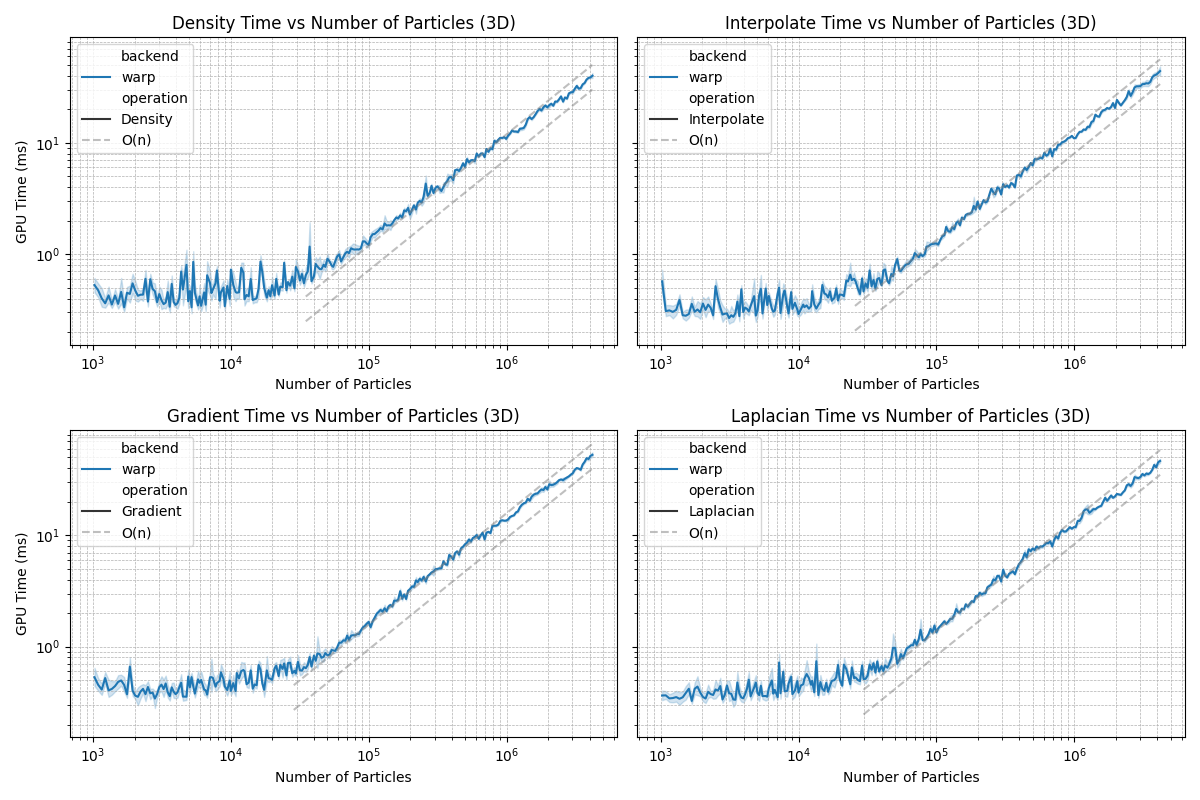

In [13]:
def add_scaling_line(ax, data, x_col, y_col, scale_factor=0.1, color='gray', linestyle='--', alpha=0.5):
    x_vals = data[x_col].unique()
    x_vals = np.sort(x_vals)
    y_mean = data.groupby(x_col)[y_col].mean()
    
    y_max = y_mean.max()
    y_min = y_mean.min()
    
    x_ref = x_vals[0]
    
    # print(f"x_vals: {x_vals}")
    # print(f"y_min: {y_min}, y_max: {y_max}")
    
    upper_scale = y_max * (1 + scale_factor)
    lower_scale = y_min * (1 + scale_factor)
    
    # now we want the line to go from [x, lower_scale] to [xmax, upper_scale] with a slope of 1 in log-log space, which means it should be a line of the form y = C * x, where C is a constant that we can determine based on the reference point (x_ref, y_ref)
    # print(f"upper_scale: {upper_scale}, lower_scale: {lower_scale}")
    y_ratio = upper_scale / lower_scale
    # print(f"y_ratio: {y_ratio}")
    x_lower = x_vals[-1] * (lower_scale / upper_scale)
    # print(f"x_lower: {x_lower}")
    ax.plot([x_lower, x_vals[-1]], [lower_scale, upper_scale], color=color, linestyle=linestyle, alpha=alpha, label='O(n)')
    
    upper_scale = y_max * (1 - scale_factor)
    lower_scale = y_min * (1 - scale_factor)
    y_ratio = upper_scale / lower_scale
    x_lower = x_vals[-1] * (lower_scale / upper_scale)
    ax.plot([x_lower, x_vals[-1]], [lower_scale, upper_scale], color=color, linestyle=linestyle, alpha=alpha)
    
scale_factor = 0.25    

fig, axis = plt.subplots(2, 2, figsize = (12,8), squeeze = False, sharey = True)
import copy

plotData = copy.deepcopy(pdData)

def plotOp(data, operation, ax):
    curData =  data[data['operation'] == operation]

    sns.lineplot(data = curData, x = 'numParticles', y = 'gpuTime', style = 'operation', hue = 'backend', ax = ax, marker = None)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Number of Particles')
    ax.set_ylabel('GPU Time (ms)')
    ax.set_title(f'{operation} Time vs Number of Particles (3D)')
    ax.grid(True, which = 'both', linestyle='--', linewidth=0.5)
    add_scaling_line(ax, curData, 'numParticles', 'gpuTime', scale_factor=scale_factor)
    ax.legend()

plotOp(plotData, 'Density', axis[0, 0])
plotOp(plotData, 'Interpolate', axis[0, 1])
plotOp(plotData, 'Gradient', axis[1, 0])
plotOp(plotData, 'Laplacian', axis[1, 1])

fig.tight_layout()